In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from pathlib import Path
import time
from tqdm import tqdm
import matplotlib.pyplot as plt

from Model import InpaintingDataset, UNetInpainting, loss_fn
from Helper import *

In [4]:
# Configuration
IMAGE_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 2000
TRAIN_SAMPLES_PER_EPOCH = 1024
VAL_SAMPLES_PER_EPOCH = 256
LR = 1e-4

CHECKPOINT_INTERVAL = 10
LOG_INTERVAL = 1
VAL_INTERVAL = 1

DATASET_PATH_TRAIN = "datasets/DIV2K/DIV2K_train_HR"
DATASET_PATH_TEST = "datasets/DIV2K/DIV2K_valid_HR"
CHECKPOINT_DIR = "checkpoints/inpainting"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create checkpoint directory
Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)

Using device: cuda


In [5]:
# Initialize datasets
print("\n=== Creating Training Dataset ===")
train_dataset = InpaintingDataset(
    image_dir=DATASET_PATH_TRAIN,
    checkpoint_dir=CHECKPOINT_DIR,
    length=TRAIN_SAMPLES_PER_EPOCH,
    image_size=IMAGE_SIZE,
    num_strokes=(4, 5),
    thickness=(7, 9),
    mode='random',
)

print("\n=== Creating Validation Dataset ===")
val_dataset = InpaintingDataset(
    image_dir=DATASET_PATH_TEST,
    checkpoint_dir=CHECKPOINT_DIR,
    length=VAL_SAMPLES_PER_EPOCH,
    image_size=IMAGE_SIZE,
    num_strokes=(4, 5),
    thickness=(7, 9),
    mode='pregenerated',
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# Initialize model
model = UNetInpainting().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Training state
start_epoch = 0
best_val_loss = float('inf')
train_losses = []
val_losses = []

# Load checkpoint if exists
checkpoint = load_checkpoint_generic(CHECKPOINT_DIR, device)
if checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])
    print(f"  Resuming from epoch {start_epoch}")
    print(f"  Best validation loss: {best_val_loss:.6f}")


=== Creating Training Dataset ===
✓ Random mode: picking from 800 images

=== Creating Validation Dataset ===
✓ Loaded existing dataset checkpoint (pregenerated mode)
✅ Loaded checkpoint: checkpoints/inpainting\checkpoint_epoch_1010.pth (epoch 1010)
  Resuming from epoch 1011
  Best validation loss: 0.129960


In [4]:
# Training loop
print(f"\n=== Starting Training ===")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LR}")
print(f"Train samples per epoch: {TRAIN_SAMPLES_PER_EPOCH}")
print(f"Validation samples: {VAL_SAMPLES_PER_EPOCH}")

for epoch in range(start_epoch, EPOCHS + 1):
    # ============ TRAINING ============
    model.train()
    epoch_train_loss = 0.0
    batches_seen = 0
    train_start = time.time()

    for masked_img, mask, original_img in train_loader:
        masked_img = masked_img.to(device)
        mask = mask.to(device)
        original_img = original_img.to(device)

        optimizer.zero_grad()

        # Forward pass
        predicted = model(masked_img, mask)

        # Calculate loss (only on holes)
        loss = loss_fn(predicted, original_img, mask)

        # Backward pass
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        batches_seen += 1

    epoch_train_loss /= batches_seen
    train_losses.append(epoch_train_loss)
    train_time = time.time() - train_start

    # ============ VALIDATION ============
    epoch_val_loss = None
    val_time = None

    if epoch % VAL_INTERVAL == 0:
        model.eval()
        epoch_val_loss = 0.0
        val_batches = 0
        val_start = time.time()

        with torch.no_grad():
            for masked_img, mask, original_img in val_loader:
                masked_img = masked_img.to(device)
                mask = mask.to(device)
                original_img = original_img.to(device)

                # Forward pass
                predicted = model(masked_img, mask)

                # Calculate loss
                loss = loss_fn(predicted, original_img, mask)

                epoch_val_loss += loss.item()
                val_batches += 1

        epoch_val_loss /= val_batches
        val_losses.append(epoch_val_loss)
        val_time = time.time() - val_start

    # ============ LOGGING ============
    if epoch % LOG_INTERVAL == 0:
        log_str = f"Epoch [{epoch:4d}/{EPOCHS}] | Train Loss: {epoch_train_loss:.5f} | Train Time: {train_time:.1f}s"

        if epoch_val_loss is not None:
            log_str += f" | Val Loss: {epoch_val_loss:.5f} | Val Time: {val_time:.1f}s"

        print(log_str)

    # ============ BEST MODEL ============
    if epoch_val_loss is not None and epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
        }
        torch.save(best_checkpoint, Path(CHECKPOINT_DIR) / "best_model.pth")
        print(f"✓ Saved best model (Val Loss: {best_val_loss:.5f})")

    # ============ REGULAR CHECKPOINT ============
    if epoch % CHECKPOINT_INTERVAL == 0:
        save_checkpoint_generic(
            CHECKPOINT_DIR,
            epoch,
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_losses": train_losses,
                "val_losses": val_losses,
                "best_val_loss": best_val_loss,
            },
            max_checkpoints=5,
        )

print("\n🎉 Training completed!")
print(f"📊 Final statistics:")
print(f"  - Best validation loss: {best_val_loss:.6f}")
print(f"  - Total validation points: {len(val_losses)}")
print(f"  - Total training loss logs: {len(train_losses)}")


=== Starting Training ===
Epochs: 2000
Batch size: 32
Learning rate: 0.0001
Train samples per epoch: 1024
Validation samples: 256
Epoch [ 771/2000] | Train Loss: 0.13793 | Train Time: 16.0s | Val Loss: 0.13431 | Val Time: 9.3s
Epoch [ 772/2000] | Train Loss: 0.13309 | Train Time: 15.7s | Val Loss: 0.13422 | Val Time: 9.3s
Epoch [ 773/2000] | Train Loss: 0.13736 | Train Time: 15.7s | Val Loss: 0.13297 | Val Time: 9.1s
Epoch [ 774/2000] | Train Loss: 0.14015 | Train Time: 15.8s | Val Loss: 0.13355 | Val Time: 9.2s
Epoch [ 775/2000] | Train Loss: 0.13588 | Train Time: 15.7s | Val Loss: 0.13327 | Val Time: 8.9s
Epoch [ 776/2000] | Train Loss: 0.13657 | Train Time: 15.6s | Val Loss: 0.13285 | Val Time: 9.0s
Epoch [ 777/2000] | Train Loss: 0.13260 | Train Time: 15.8s | Val Loss: 0.13282 | Val Time: 8.8s
Epoch [ 778/2000] | Train Loss: 0.13526 | Train Time: 15.7s | Val Loss: 0.13335 | Val Time: 8.9s
Epoch [ 779/2000] | Train Loss: 0.13934 | Train Time: 15.8s | Val Loss: 0.13291 | Val Time: 8

KeyboardInterrupt: 

In [6]:
def plot_losses(train_losses, val_losses, val_interval):
    """
    Plot training and validation losses.

    Args:
        train_losses: List of training loss values (one per epoch)
        val_losses: List of validation loss values (one per val_interval epochs)
        val_interval: How often validation occurs (e.g., every 1, 5, 10 epochs)
    """
    # Create epoch arrays
    train_epochs = list(range(1, len(train_losses) + 1))
    val_epochs = list(range(val_interval, len(val_losses) * val_interval + 1, val_interval))

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(train_epochs, train_losses, label='Train Loss', linewidth=2)
    plt.plot(val_epochs, val_losses, label='Val Loss', linewidth=2, marker='o', markersize=4)

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

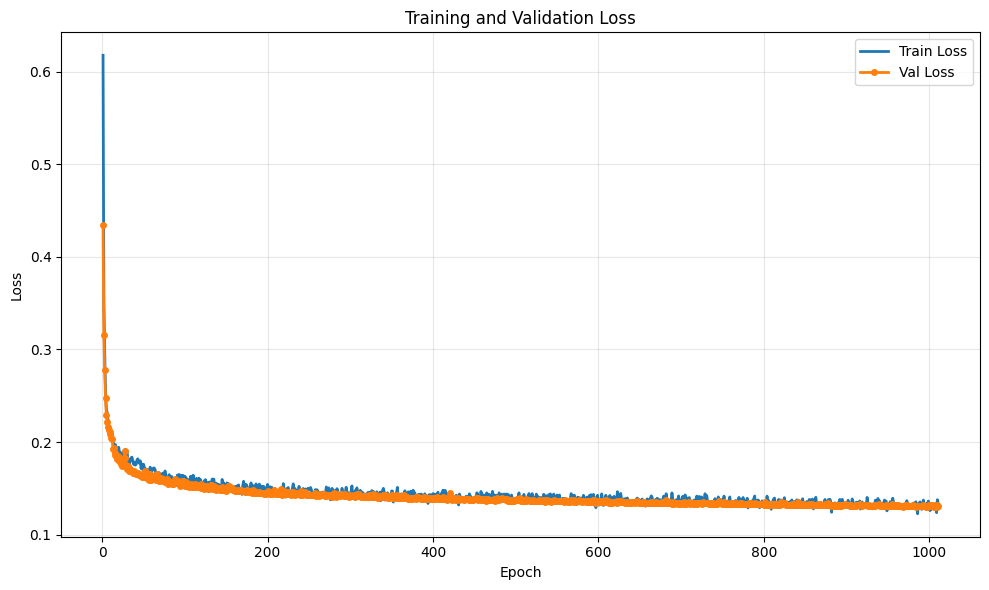

In [7]:
plot_losses(train_losses, val_losses, VAL_INTERVAL)